Columns assigned: ['ID', 'Current', 'Unit', 'Hours', 'Batch']
First 3 rows:
  ID Current Unit Hours Batch
1  1       0  101     0     1
2  2  0.4741  101   250     1
3  3  0.9255  101   500     1


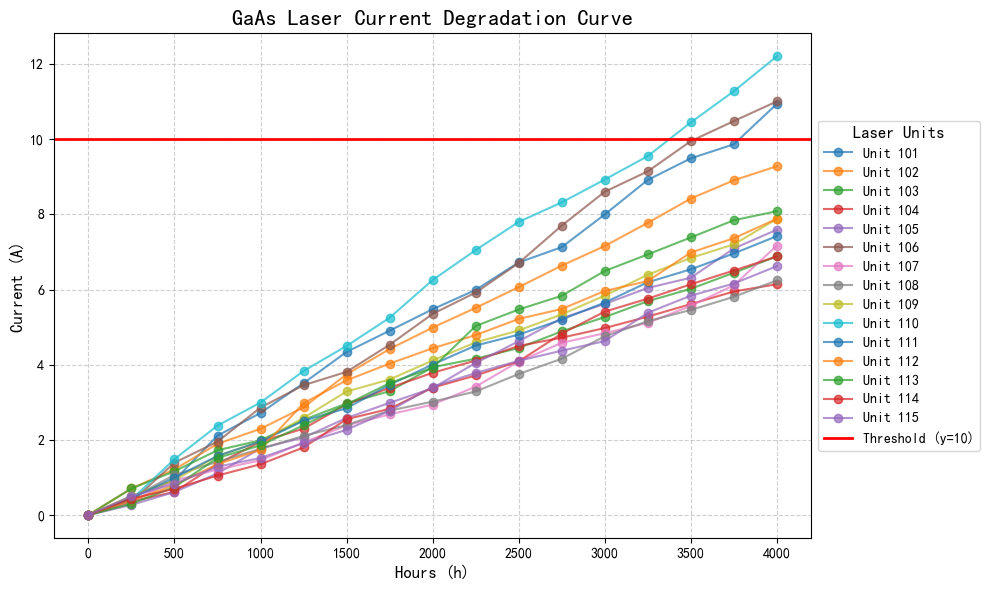

Plotting completed.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

file_path = r'data\课题一\project1附件-GaAs激光器退化数据.xlsx'

try:
    df = pd.read_excel(file_path, skiprows=1, header=None)
    
    df.columns = ['ID', 'Current', 'Unit', 'Hours', 'Batch']

    df = df[df['Unit'] != '单元']
    df = df.dropna(subset=['Hours', 'Current'])

    print(f"Columns assigned: {df.columns.tolist()}")
    print(f"First 3 rows:\n{df.head(3)}")

    df['Hours'] = pd.to_numeric(df['Hours'], errors='coerce')
    df['Current'] = pd.to_numeric(df['Current'], errors='coerce')
    df['Unit'] = df['Unit'].astype(str) # Treat 'Unit' as a categorical variable

    plt.figure(figsize=(10, 6))

    grouped = df.groupby('Unit')
    
    for name, group in grouped:
        group = group.sort_values('Hours')
        plt.plot(group['Hours'], group['Current'], marker='o', label=f'Unit {name}', alpha=0.7)

    plt.axhline(y=10, color='red', linewidth=2, label='Threshold (y=10)')

    plt.title('GaAs Laser Current Degradation Curve', fontsize=16)
    plt.xlabel('Hours (h)', fontsize=12)
    plt.ylabel('Current (A)', fontsize=12)

    plt.legend(
        title='Laser Units', 
        bbox_to_anchor=(1.0, 0.5),  # Anchor point at right center (Y=0.5)
        loc='center left',           # Align legend's left-center to the anchor
        fontsize=10,                 # Increase list font size
        title_fontsize=12            # Increase title font size
    )    
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    plt.show()

    print("Plotting completed.")

except FileNotFoundError:
    print(f"Error: File not found at {file_path}. Please check the file path.")
except Exception as e:
    print(f"An error occurred: {e}")
    try:
        print(f"Debug Info - Columns: {df.columns.tolist()}")
        print(f"Debug Info - Head:\n{df.head()}")
    except:
        pass

In [8]:
import numpy as np

unit_list = []
time_list = []
current_list = []

for name, group in grouped:
    group_sorted = group.sort_values('Hours')

    unit_list.append(name)
    time_list.append(group_sorted['Hours'].to_numpy())
    current_list.append(group_sorted['Current'].to_numpy())

units_arr = np.array(unit_list)
time_arr = np.array(time_list) 
current_arr = np.array(current_list)

print(f"Units: {units_arr}")
print(f"Time data shape: {time_arr.shape}(dtype={time_arr.dtype})")
print(f"Current data shape: {current_arr.shape}(dtype={current_arr.dtype})")

print("="*60)
print("Sample time data for each unit:")
for i, unit in enumerate(units_arr):
    print(f"Unit: {unit}")
    print(f"Time data: {time_arr[i]}")
    print(f"Current data: {current_arr[i]}")
    print("-" * 40)

Units: ['101' '102' '103' '104' '105' '106' '107' '108' '109' '110' '111' '112'
 '113' '114' '115']
Time data shape: (15, 17)(dtype=int64)
Current data shape: (15, 17)(dtype=float64)
Sample time data for each unit:
Unit: 101
Time data: [   0  250  500  750 1000 1250 1500 1750 2000 2250 2500 2750 3000 3250
 3500 3750 4000]
Current data: [ 0.      0.4741  0.9255  2.1147  2.7168  3.511   4.3415  4.9076  5.4782
  5.9925  6.7224  7.1303  8.0006  8.9193  9.494   9.8675 10.9446]
----------------------------------------
Unit: 102
Time data: [   0  250  500  750 1000 1250 1500 1750 2000 2250 2500 2750 3000 3250
 3500 3750 4000]
Current data: [0.     0.7078 1.2175 1.8955 2.2954 2.865  3.7454 4.4192 4.9894 5.5148
 6.0668 6.6385 7.1615 7.7778 8.4242 8.9092 9.2834]
----------------------------------------
Unit: 103
Time data: [   0  250  500  750 1000 1250 1500 1750 2000 2250 2500 2750 3000 3250
 3500 3750 4000]
Current data: [0.     0.7074 1.1651 1.7253 1.9888 2.5325 2.9695 3.2977 3.9354 4.1613
 4

In [9]:
from scipy.optimize import curve_fit
import warnings

# ==================== 模型定义 ====================
# 1. 指数退化模型
def exp_model(t, c, d):
    # 使用 np.float64 防止溢出警告
    return c * np.exp(d * t.astype(np.float64))

# 2. 幂函数退化模型
def pow_model(t, c, d):
    return c * np.power(t.astype(np.float64), d)

# 失效阈值
threshold = 10.0  

# 存储所有单元的拟合结果
results = []

for i, unit in enumerate(units_arr):
    t_data = time_arr[i]
    x_data = current_arr[i]
    
    # 过滤掉可能的缺失值 (NaN)
    valid = ~np.isnan(t_data) & ~np.isnan(x_data)
    t_data = t_data[valid].astype(float)
    x_data = x_data[valid].astype(float)
    
    unit_res = {'Unit': unit}
    
    # ---------------- 拟合指数退化模型 ----------------
    try:
        # 初始参数猜测: c 约为 t=0 时的初始电流，d 猜测为一个较小的正向增长率
        p0_exp = [x_data[0] if len(x_data) > 0 else 1.0, 0.001]
        
        # 使用 curve_fit 进行拟合
        popt_exp, _ = curve_fit(exp_model, t_data, x_data, p0=p0_exp, maxfev=10000)
        c_exp, d_exp = popt_exp
        
        # 计算指数模型的失效时间
        if c_exp > 0 and d_exp != 0:
            ttf_exp = np.log(threshold / c_exp) / d_exp
        else:
            ttf_exp = np.nan
            
        unit_res['Exp_c'] = c_exp
        unit_res['Exp_d'] = d_exp
        unit_res['Exp_TTF (h)'] = ttf_exp
    except Exception as e:
        print(f"单元 {unit} 指数模型拟合失败: {e}")
        unit_res['Exp_c'], unit_res['Exp_d'], unit_res['Exp_TTF (h)'] = np.nan, np.nan, np.nan

    # ---------------- 拟合幂函数退化模型 ----------------
    try:
        # 对于幂函数模型，当 t=0 时，如果 d 为负数会导致除零错误，底数为0也可能使算法不稳定
        # 稳妥起见，我们仅使用 t > 0 的数据进行拟合
        valid_pow = t_data > 0
        t_data_pow = t_data[valid_pow]
        x_data_pow = x_data[valid_pow]
        
        # 初始参数猜测
        p0_pow = [x_data_pow[0] if len(x_data_pow) > 0 else 1.0, 0.5]
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore") # 忽略底数为负或0的计算警告
            popt_pow, _ = curve_fit(pow_model, t_data_pow, x_data_pow, p0=p0_pow, maxfev=10000)
            
        c_pow, d_pow = popt_pow
        
        # 计算幂函数模型的失效时间
        if c_pow > 0 and d_pow != 0:
            ttf_pow = np.power((threshold / c_pow), 1.0 / d_pow)
        else:
            ttf_pow = np.nan
            
        unit_res['Pow_c'] = c_pow
        unit_res['Pow_d'] = d_pow
        unit_res['Pow_TTF (h)'] = ttf_pow
    except Exception as e:
        print(f"单元 {unit} 幂函数模型拟合失败: {e}")
        unit_res['Pow_c'], unit_res['Pow_d'], unit_res['Pow_TTF (h)'] = np.nan, np.nan, np.nan
        
    results.append(unit_res)

# ==================== 输出拟合结果 ====================
# 将结果转化为 DataFrame 进行美观打印
df_results = pd.DataFrame(results)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("\n" + "="*80)
print("各单元模型拟合参数及预测失效时间 (TTF) 结果汇总:")
print(df_results.round(4))  # 结果保留4位小数

# 如果需要，你也可以将结果保存为Excel
df_results.to_excel('Degradation_Fitting_Results.xlsx', index=False)


各单元模型拟合参数及预测失效时间 (TTF) 结果汇总:
   Unit   Exp_c   Exp_d  Exp_TTF (h)   Pow_c   Pow_d  Pow_TTF (h)
0   101  1.8652  0.0005    3631.5817  0.0028  0.9948    3711.4168
1   102  1.7337  0.0004    3913.5446  0.0033  0.9614    4232.0967
2   103  1.4268  0.0004    4692.3151  0.0059  0.8504    6304.9540
3   104  1.3617  0.0004    4884.3607  0.0059  0.8419    6840.7551
4   105  1.1500  0.0005    4370.8534  0.0008  1.1092    5119.8995
5   106  1.8285  0.0005    3560.4770  0.0018  1.0530    3576.8833
6   107  1.0241  0.0005    4614.2993  0.0008  1.0955    5764.4968
7   108  1.1273  0.0004    4861.5038  0.0023  0.9523    6670.7422
8   109  1.4334  0.0004    4348.4850  0.0030  0.9488    5216.1512
9   110  2.1070  0.0005    3386.6335  0.0033  0.9893    3311.6294
10  111  1.3980  0.0004    4450.9716  0.0031  0.9386    5472.0311
11  112  1.5114  0.0004    4330.0245  0.0039  0.9176    5184.9436
12  113  1.4061  0.0005    4167.1118  0.0015  1.0413    4691.1987
13  114  1.0958  0.0005    4528.0789  0.0008  

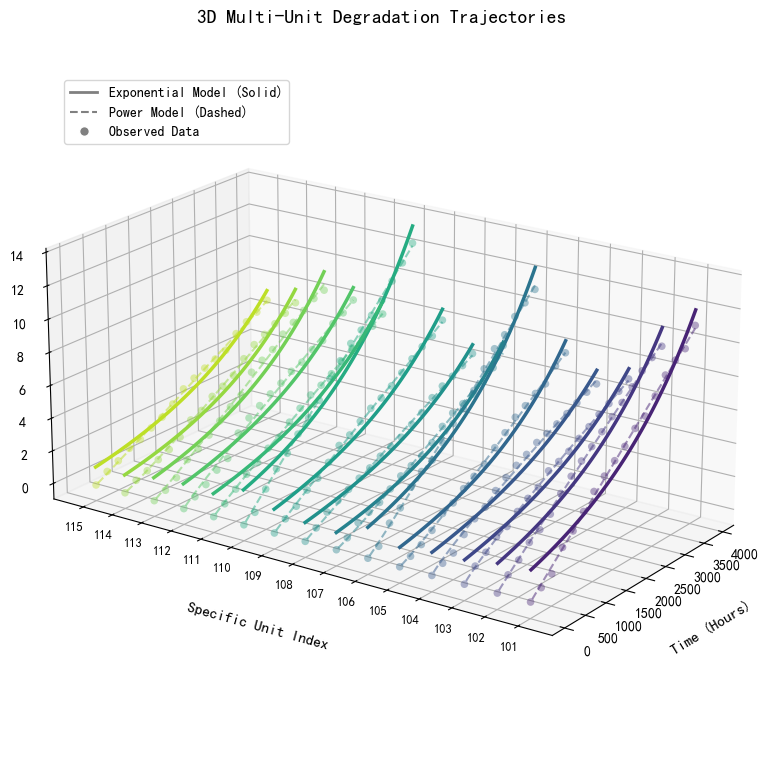

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D

# --- 1. 参数与间距设置 ---
spacing_factor = 2.5  
unit_indices = np.arange(len(units_arr)) * spacing_factor

# 稍微增大画布比例，给标签留出空间
fig = plt.figure(figsize=(13, 9)) 
ax = fig.add_subplot(111, projection='3d')
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(units_arr)))

# --- 2. 循环绘制数据 ---
for i, unit in enumerate(units_arr):
    t_raw = np.array(time_arr[i], dtype=float)
    c_raw = np.array(current_arr[i], dtype=float)
    y_pos = unit_indices[i]
    
    # 原始观测点
    ax.scatter(t_raw, [y_pos]*len(t_raw), c_raw, color=colors[i], s=30, alpha=0.4, edgecolors='none')

    # 生成拟合曲线 (从0到100)
    t_fit = np.linspace(0, 4000, 100)
    row = df_results[df_results['Unit'] == unit].iloc[0]
    
    # 指数模型 (实线)
    if not np.isnan(row['Exp_c']):
        z_exp = exp_model(t_fit, row['Exp_c'], row['Exp_d'])
        ax.plot(t_fit, [y_pos]*len(t_fit), z_exp, color=colors[i], linestyle='-', linewidth=2.5)

    # 幂函数模型 (虚线)
    if not np.isnan(row['Pow_c']):
        t_fit_pow = t_fit[t_fit > 0]
        z_pow = pow_model(t_fit_pow, row['Pow_c'], row['Pow_d'])
        ax.plot(t_fit_pow, [y_pos]*len(t_fit_pow), z_pow, color=colors[i], linestyle='--', linewidth=1.5, alpha=0.5)

# --- 3. 标签与图例 (优化版) ---

# 坐标轴标签，调大 labelpad 防止重叠
ax.set_xlabel('Time (Hours)', fontsize=11, labelpad=12)
ax.set_ylabel('Specific Unit Index', fontsize=11, labelpad=25) # Unit轴标签往外挪一点
ax.set_zlabel('Current (A)', fontsize=11, labelpad=12)

# Y轴刻度
ax.set_yticks(unit_indices)
ax.set_yticklabels(units_arr, fontsize=9)

# 手动创建自定义图例
legend_elements = [
    Line2D([0], [0], color='gray', lw=2, label='Exponential Model (Solid)'),
    Line2D([0], [0], color='gray', lw=1.5, ls='--', label='Power Model (Dashed)'),
    Line2D([0], [0], marker='o', color='w', label='Observed Data', markerfacecolor='gray', markersize=7)
]
# 调整图例位置，防止遮挡
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.05, 0.95), fontsize=10, frameon=True)

# --- 4. 视角与布局调整 ---
ax.view_init(elev=20, azim=-145) 
ax.set_box_aspect((1, 1.8, 0.8)) # 视觉拉长 Unit 轴

# 关键：手动控制子图边距，替代 tight_layout()
# 这里的数值(0到1之间)可以根据你的显示屏大小微调
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.1, top=0.9)

ax.set_title('3D Multi-Unit Degradation Trajectories', fontsize=14, pad=10)

plt.show()